<a href="https://colab.research.google.com/github/abeeraz379/literacy-rates-updated/blob/main/literacy_rates_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Literacy rates updated
- ABeer Al-Zebda | Data Scientist & Machine Learning Engineer

# Project Overview
- Literacy rate is calculated by taking the number of literate persons in that age and gender group divided by the total number of persons in that group. Literate is defined as the ability to both read and write, with understanding, a short, simple statement about everyday life. Literacy rates at or near 100% indicate that (nearly) every individual in that age range and gender group is able to read and write, at least at a basic level.


#Load and inspect data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path='/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week04/literacy_rates_updated.xlsx'
df=pd.read_excel(path)
df.head()

,Region,Country,Year,Age,Gender,Literacy rate
0,Central and Southern Asia,Afghanistan,2011,<15,female,0.176121
1,Central and Southern Asia,Afghanistan,2011,<15,male,0.454171
2,NaN,Afghanistan,2011,15-24,female,0.321132
3,NaN,Afghanistan,2011,15-24,male,0.618791
4,Central and Southern Asia,Afghanistan,2011,25-64,female,0.084128


In [ ]:
# to know more about data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3313 entries, 0 to 3312
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Region         3309 non-null   object 
 1   Country        3313 non-null   object 
 2   Year           3313 non-null   object 
 3   Age            3313 non-null   object 
 4   Gender         3313 non-null   object 
 5   Literacy rate  3308 non-null   float64
dtypes: float64(1), object(5)
memory usage: 155.4+ KB


## Data Set info
- number of column :6
- number of rows :3313

 ## Types of Columns
- 5 Categorical Columns
- 1 float Columns   

#Clean Data

## Check for duplicates

In [ ]:
df.duplicated(keep=False).sum()

np.int64(20)

In [ ]:
# delete the duplicated
df=df.drop_duplicates()
df.duplicated(keep=False).sum()

np.int64(0)

## Check for Missing Values

In [ ]:
df.isna().sum()

,0
Region,4
Country,0
Year,0
Age,0
Gender,0
Literacy rate,5


## Missing Values Rate

In [ ]:
df.isna().sum()/len(df)*100

,0
Region,0.121102
Country,0.000000
Year,0.000000
Age,0.000000
Gender,0.000000
Literacy rate,0.151378


## Handling Missing Value

In [ ]:
df[['Region','Country']].value_counts()

Region                            Country            
Latin America and the Caribbean   Uruguay                72
                                  Mexico                 72
                                  Brazil                 72
Northern Africa and Western Asia  Azerbaijan             64
Latin America and the Caribbean   Argentina              64
                                                         ..
Sub-Saharan Africa                Guinea-Bissau           8
                                  Niger                   8
                                  Nigeria                 8
                                  South Sudan             8
Latin America and the Caribbean   Antigua and Barbuda     4
Name: count, Length: 155, dtype: int64

In [ ]:
# imitate the missing value in region column with the region for the same country
df['Region']=df.groupby('Country')['Region'].ffill()

In [ ]:
df['Region'].value_counts()

,count
Region,
Latin America and the Caribbean,940
Sub-Saharan Africa,770
Northern Africa and Western Asia,568
Europe and Northern America,336
Central and Southern Asia,311
Eastern and South-Eastern Asia,282
Oceania,96


In [ ]:
# drop the rows that have missing value in Literacy rate column
df=df.dropna(subset=['Literacy rate'])

<Axes: >

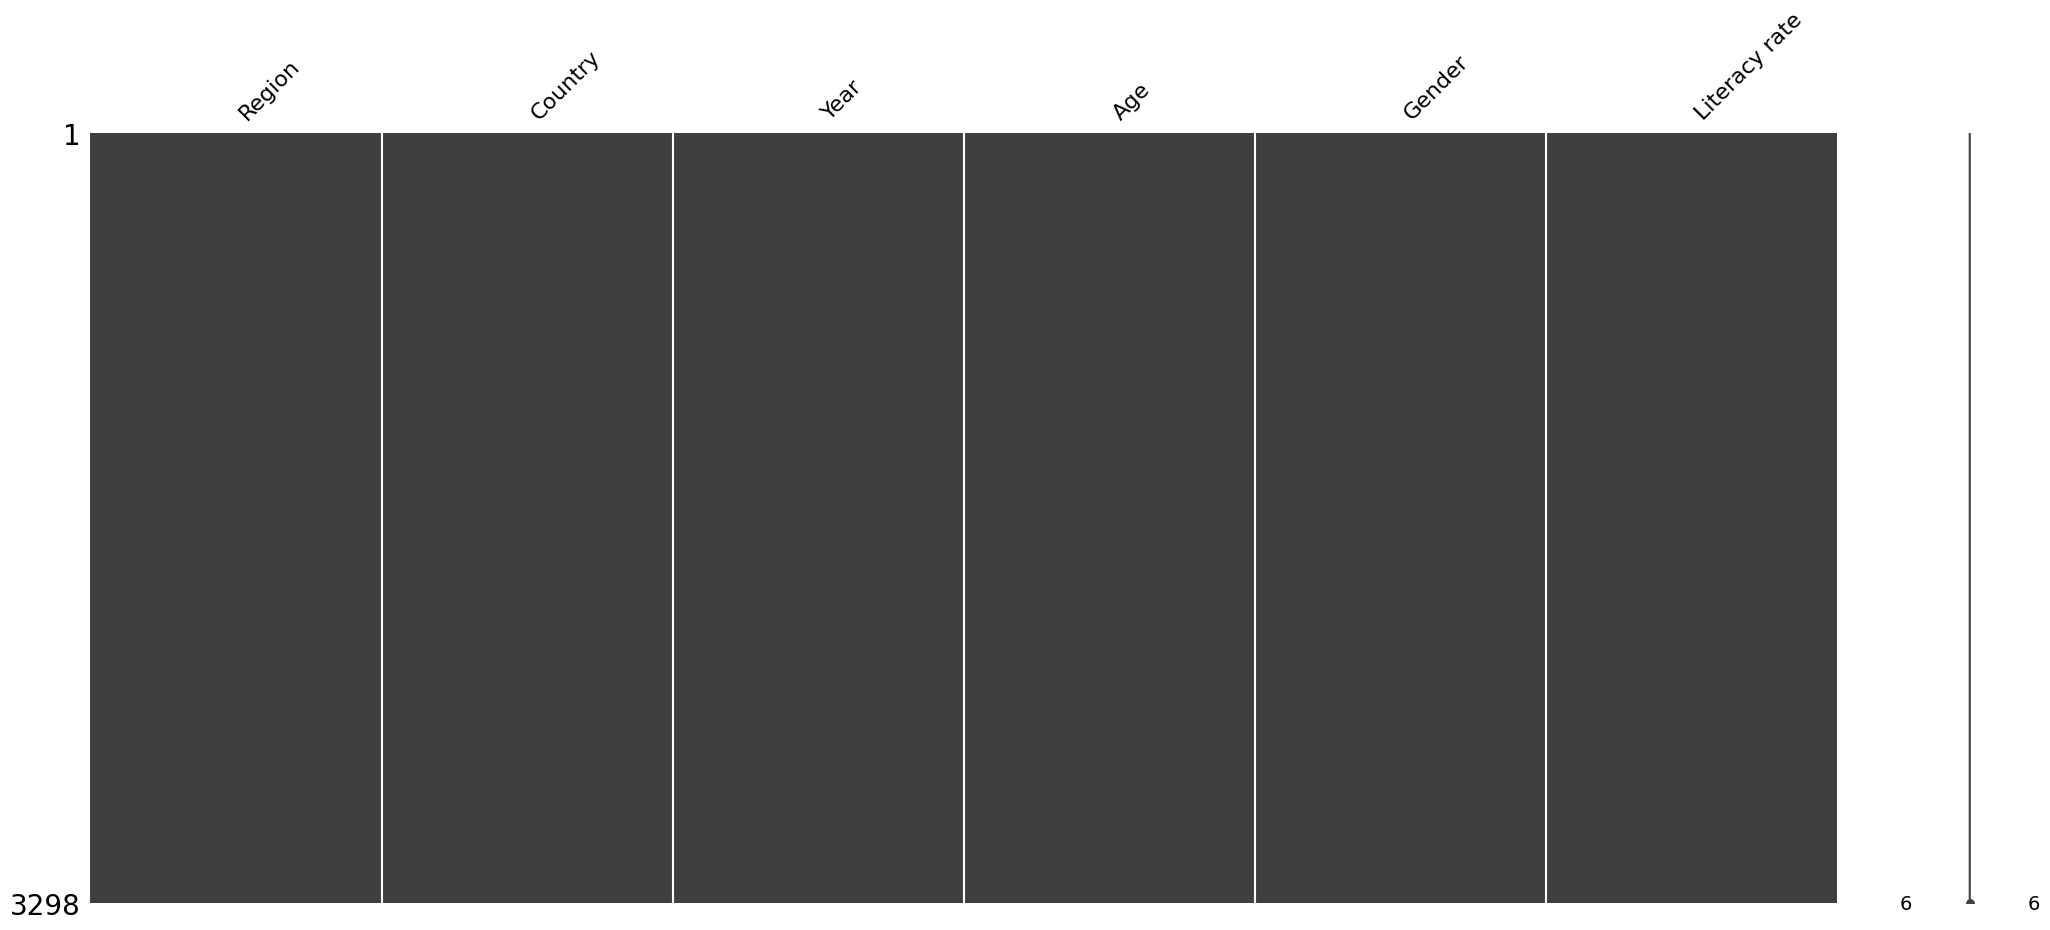

In [ ]:
import missingno as msno
msno.matrix(df)

## Check Consistancy

In [ ]:
# see the values for each column with it frequency to check the consistancy
for col in df.columns:
  print( df[col].value_counts())
  print('\n')

Region
Latin America and the Caribbean     940
Sub-Saharan Africa                  770
Northern Africa and Western Asia    568
Europe and Northern America         332
Central and Southern Asia           311
Eastern and South-Eastern Asia      281
Oceania                              96
Name: count, dtype: int64


Country
Uruguay                72
Mexico                 72
Brazil                 72
Palestine              64
Azerbaijan             64
                       ..
Guinea-Bissau           8
Niger                   8
Nigeria                 8
South Sudan             8
Antigua and Barbuda     4
Name: count, Length: 155, dtype: int64


Year
2018     574
2011     453
2014     439
2010     398
2012     343
2015     316
2016     264
2013     263
2017     246
2011_      1
3014       1
Name: count, dtype: int64


Age
<15      839
25-64    825
15-24    824
65+      810
Name: count, dtype: int64


Gender
female    1646
male      1645
F            4
M            3
Name: count, dtype: int

## Handling inconstancy

In [ ]:
# replace the inconstancy values with the right values
df['Gender']=df['Gender'].replace({'F':'female','M':'male'})

In [ ]:
# check to make sure that data now is clean
df['Gender'].value_counts()

,count
Gender,
female,1650
male,1648


In [ ]:
df['Year']=df['Year'].replace({'2011_':2011 , 3014: 2014})

/tmp/ipykernel_445/2846950220.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Year']=df['Year'].replace({'2011_':2011 , 3014: 2014})


In [ ]:
df['Year'].value_counts()

,count
Year,
2018,574
2011,454
2014,440
2010,398
2012,343
2015,316
2016,264
2013,263
2017,246


## Save the clean data

In [ ]:
# save the clean data into new file called cleaning product sales using to_csv
fpath='/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week04/Data/Cleaning_literacy_rates.csv'
new_df=df.to_csv(fpath,index=False)


In [ ]:
new_df=pd.read_csv(fpath)
new_df.head()

,Region,Country,Year,Age,Gender,Literacy rate
0,Central and Southern Asia,Afghanistan,2011,<15,female,0.176121
1,Central and Southern Asia,Afghanistan,2011,<15,male,0.454171
2,Central and Southern Asia,Afghanistan,2011,15-24,female,0.321132
3,Central and Southern Asia,Afghanistan,2011,15-24,male,0.618791
4,Central and Southern Asia,Afghanistan,2011,25-64,female,0.084128


#Exploratory Data Analysis

## count plot

/tmp/ipykernel_445/981364261.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0][0].set_xticklabels(ax[0][0].get_xticklabels(),rotation=90);
/tmp/ipykernel_445/981364261.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0][1].set_xticklabels(ax[0][1].get_xticklabels(),rotation=90);
/tmp/ipykernel_445/981364261.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1][1].set_xticklabels(ax[1][1].get_xticklabels(),rotation=90);


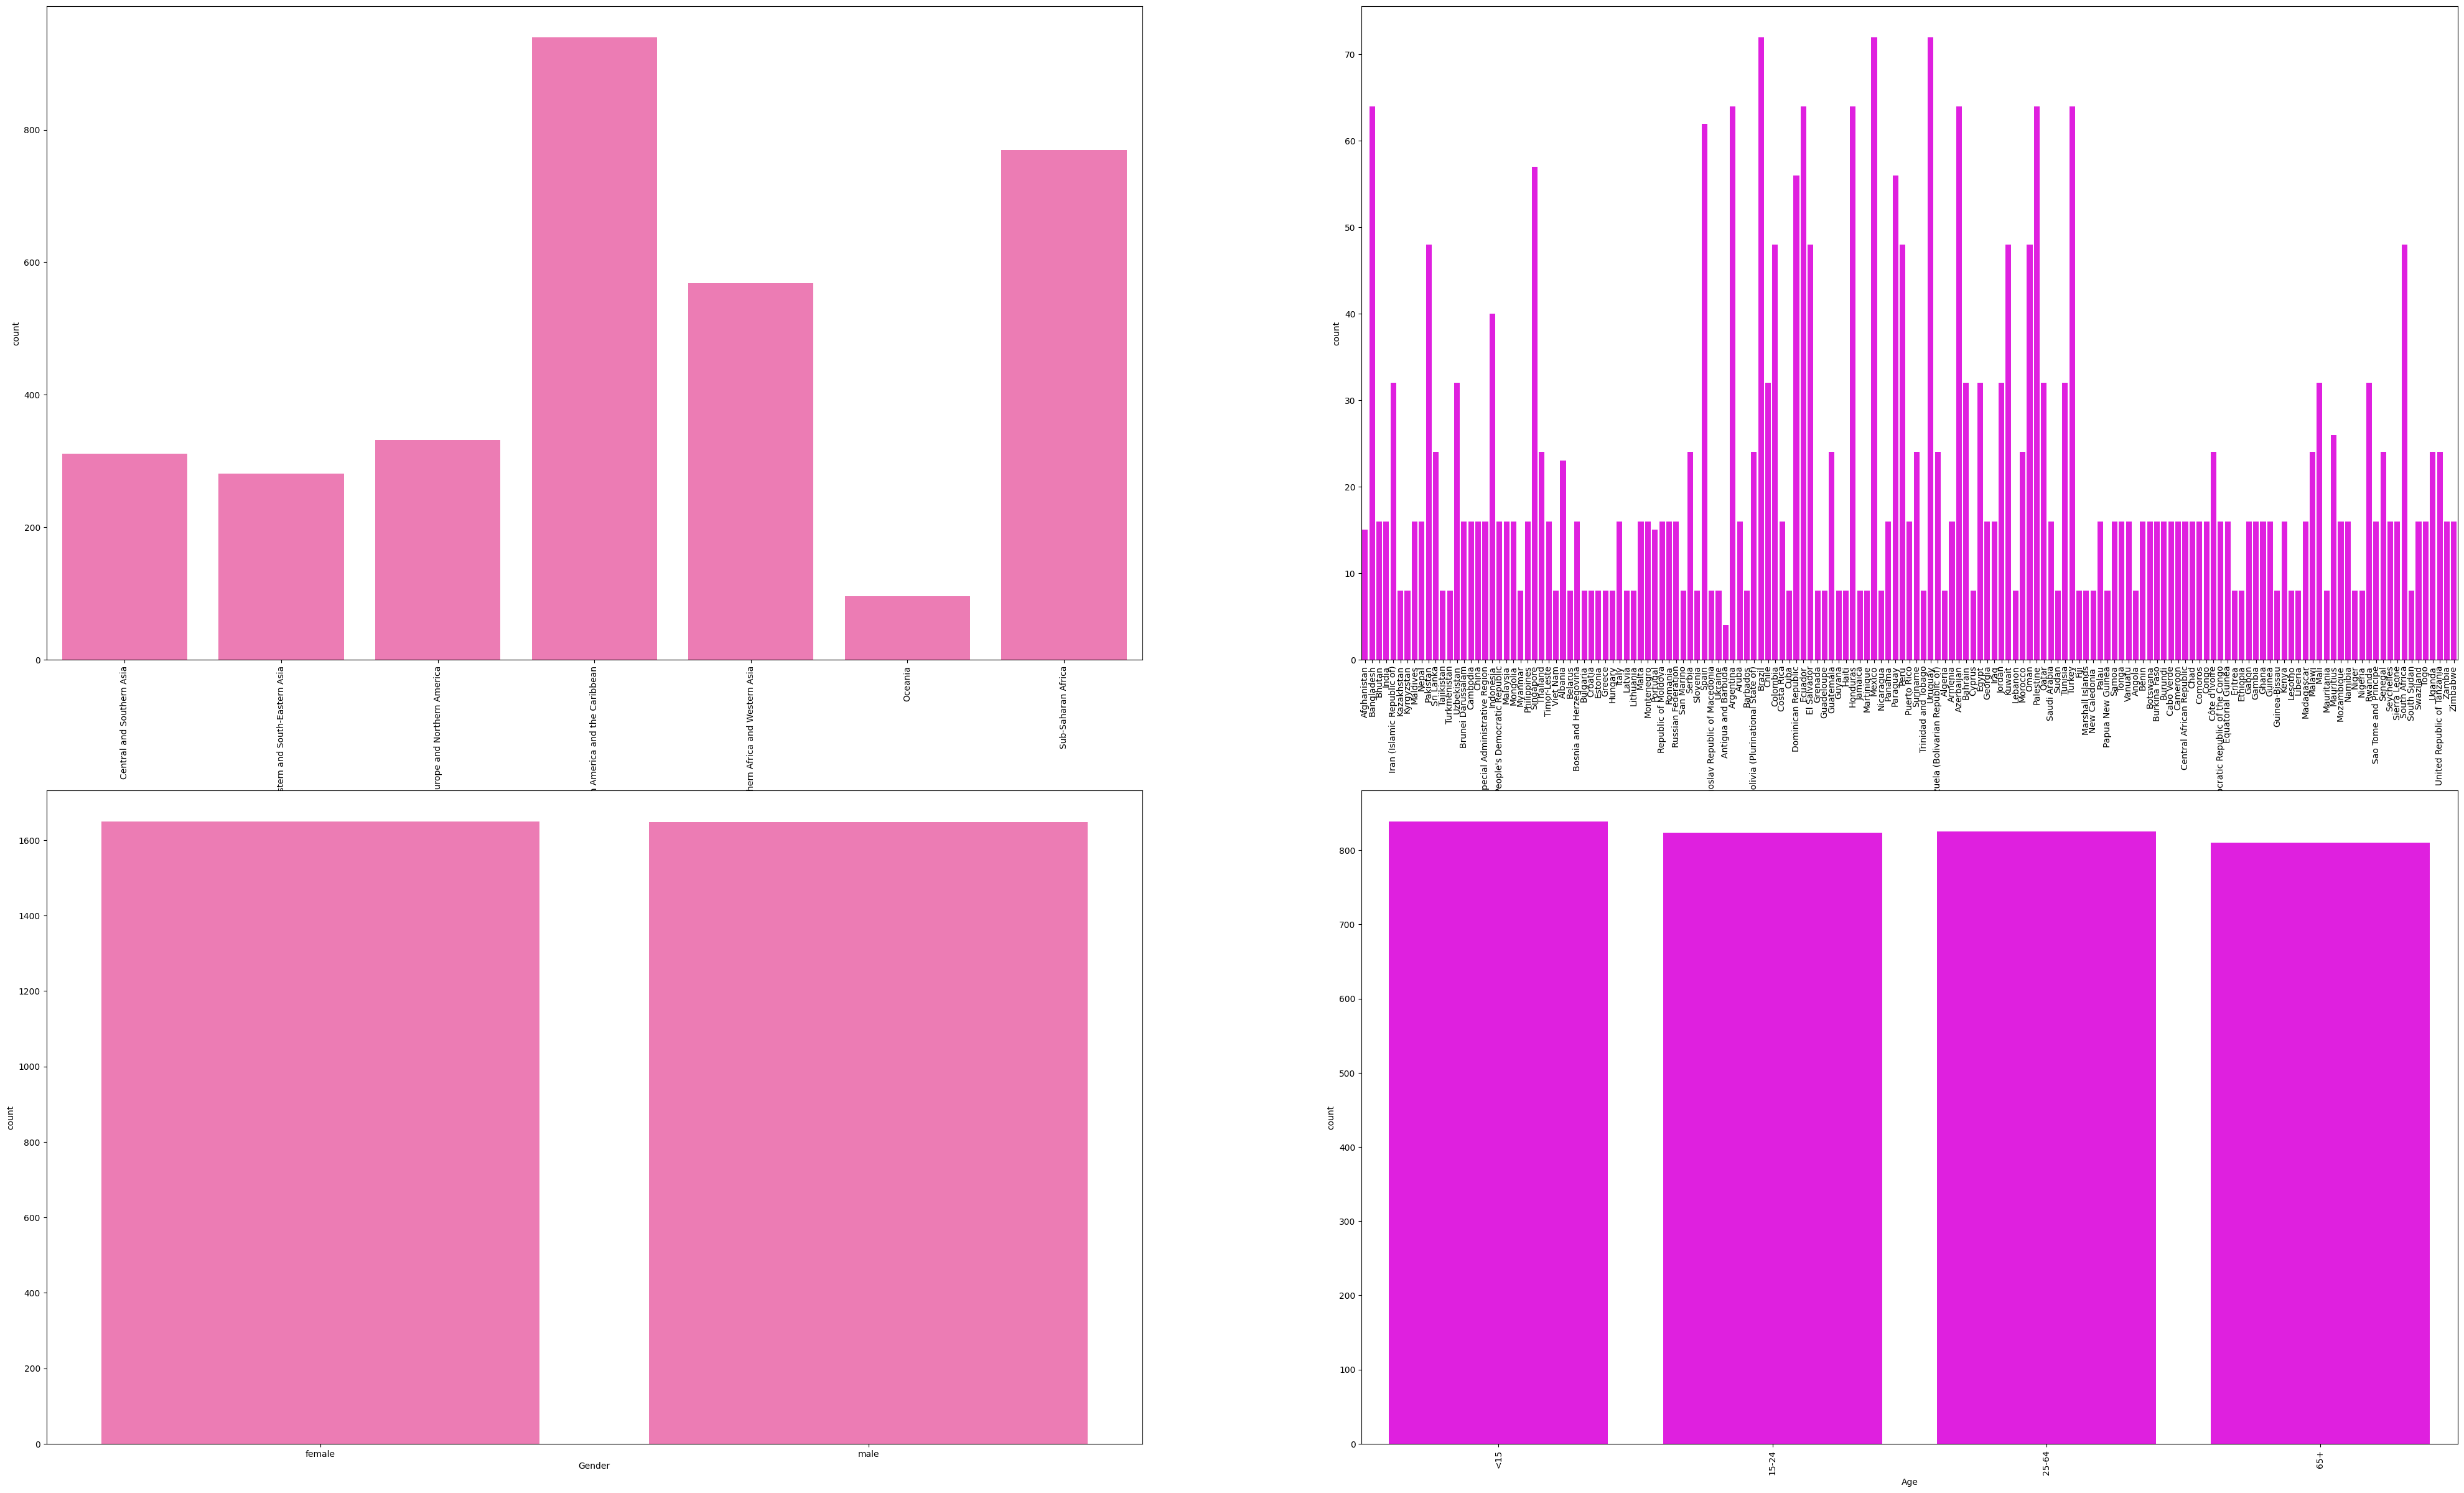

In [ ]:
# draw a count plot to show the frequency of each category
# make a count plots for the categorical columns
fig,ax=plt.subplots(ncols=2,nrows=2,figsize=(50,30))
ax[0][0]=sns.countplot(x='Region',data=new_df,ax=ax[0][0],color='#FF69B4')
ax[0][0].set_title='count of Region '
ax[0][0].set_xticklabels(ax[0][0].get_xticklabels(),rotation=90);

ax[0][1]=sns.countplot(x='Country',data=new_df,ax=ax[0][1],color='#FF00FF')
ax[0][1].set_title='count of Countries'
ax[0][1].set_xticklabels(ax[0][1].get_xticklabels(),rotation=90);

ax[1][0]=sns.countplot(x='Gender',data=new_df,ax=ax[1][0],color='#FF69B4')
ax[1][0].set_title='count of Gender'

ax[1][1]=sns.countplot(x='Age',data=new_df,ax=ax[1][1],color='#FF00FF')
ax[1][1].set_title='count of Age '
ax[1][1].set_xticklabels(ax[1][1].get_xticklabels(),rotation=90);

## bar plot

In [ ]:
# make a bar plot for country vs Literacy rate
sns.barplot(x='Region',y='Literacy rate',data=new_df,color='#FF69B4')


NameError: name 'sns' is not defined

## box plot

In [ ]:
# make a box plot for Age vs Literacy rate with hue gender
sns.barplot(x='Age',y='Literacy rate',data=new_df,color='#FF69B4',hue='Gender')


#Future Inspection

In [ ]:
"""UNIVARIATE PLOTTING FUNCTIONS FOR EDA"""
# Add the print statements to the function
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):
  """Creates a seaborn countplot with the option to temporarily fill missing values
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}", fontweight='bold')

  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")
  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100
  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax


"""MULTIVARIATE PLOTTING FUNCTIONS VS. NUMERIC TARGET"""

def plot_categorical_vs_target(df, x, y='item_Outlet_sales',figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None):
  """Plots a combination of a seaborn barplot of means combined with
  a seaborn stripplot to show the spread of the data.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)

  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)

    # Barplot
  sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  # Boxplot
  sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                order=order, hue_order=order, legend=False,
                edgecolor='white', linewidth=0.5,
                size=3,zorder=0)
  # Rotate xlabels
  plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}", fontweight='bold')
  fig.tight_layout()
  return fig, ax




In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_categorical_vs_target2(df, x, y, figsize=(6,4), fillna = True, placeholder = "MISSING", order = None):
    # Make a copy of the dataframe and fillna
    temp_df = df.copy()
    # fillna with placeholder if fillna == True:
    if fillna == True:
        temp_df[x] = temp_df[x].fillna(placeholder)
    # or drop nulls prevent unwanted nan group in stripplot
    else:
        temp_df = temp_df.dropna(subset=[x])

    # Create the figure and subplots
    fig, ax = plt.subplots(figsize=figsize)

    # --- CHANGED LINE ---
    # Added estimator=sum to calculate total instead of mean
    sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
                linewidth=1, edgecolor='black', errorbar=None, estimator=sum)
    # --------------------

    # Boxplot
    sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax, order=order,
                  hue_order=order, legend=False, edgecolor='white',
                  linewidth=0.5, size=3, zorder=0)

    # Rotate xlabels
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # Add a title
    ax.set_title(f"{x} vs. {y} (Sum)", fontweight='bold')
    fig.tight_layout()
    return fig, ax


## Feature 1 : {Region}

- Region

In [ ]:
# Confirming the dtype to select correct EDA function
feature='Region'
new_df[feature].dtype

dtype('O')

/tmp/ipykernel_766/1613442045.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


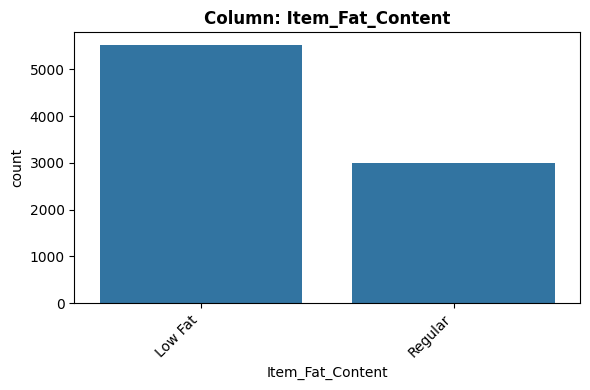

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'Low Fat' occurs 5517 times (64.73%)
- Not constant or quasi-constant.


In [ ]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(new_df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - categorical

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 2 unique values (low)

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  -No



/tmp/ipykernel_766/2400736708.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Fat_Content vs. Item_Outlet_Sales'}, xlabel='Item_Fat_Content', ylabel='Item_Outlet_Sales'>)

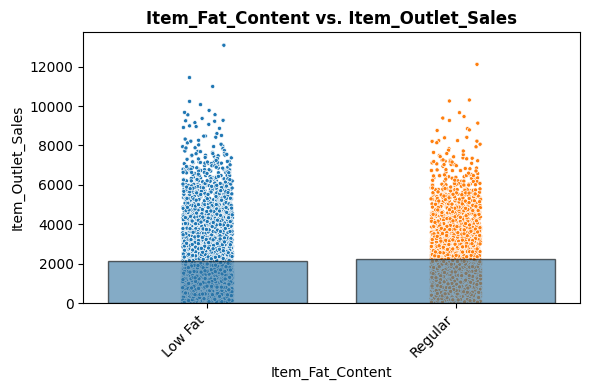

In [ ]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(new_df,feature ,'Item_Outlet_Sales' , )

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No.
  - Does this feature appear to be a predictor of the target?
    - No.

___

## Feature 2 : {Country}

- Country

In [ ]:
# Confirming the dtype to select correct EDA function
feature='Country'
new_df[feature].dtype

dtype('O')

/tmp/ipykernel_766/1613442045.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


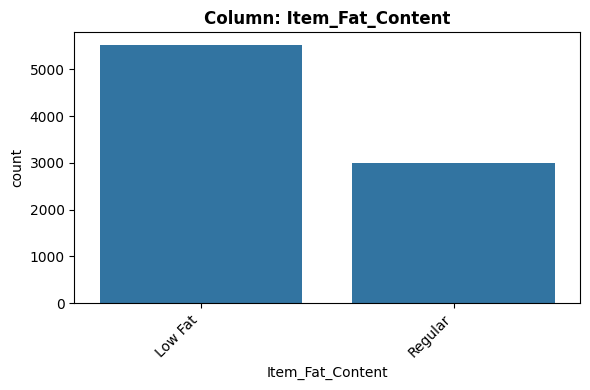

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'Low Fat' occurs 5517 times (64.73%)
- Not constant or quasi-constant.


In [ ]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(new_df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - categorical

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 2 unique values (low)

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  -No



/tmp/ipykernel_766/2400736708.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Fat_Content vs. Item_Outlet_Sales'}, xlabel='Item_Fat_Content', ylabel='Item_Outlet_Sales'>)

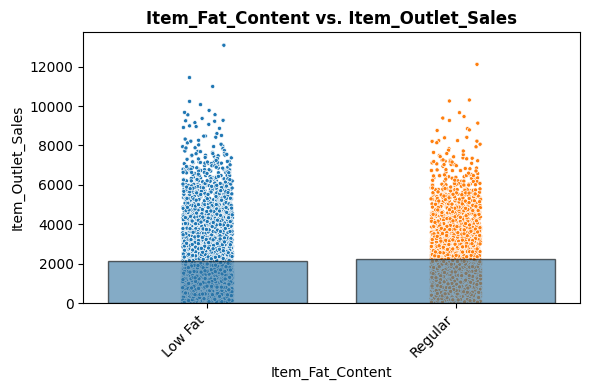

In [ ]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(new_df,feature ,'Item_Outlet_Sales' , )

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No.
  - Does this feature appear to be a predictor of the target?
    - No.

___

## Feature 3 : {Year}

- Year

In [ ]:
# Confirming the dtype to select correct EDA function
feature='Year'
new_df[feature].dtype

dtype('O')

/tmp/ipykernel_766/1613442045.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


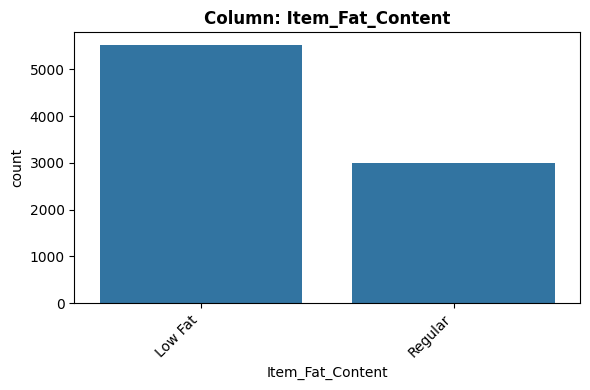

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'Low Fat' occurs 5517 times (64.73%)
- Not constant or quasi-constant.


In [ ]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(new_df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - categorical

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 2 unique values (low)

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  -No



/tmp/ipykernel_766/2400736708.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Fat_Content vs. Item_Outlet_Sales'}, xlabel='Item_Fat_Content', ylabel='Item_Outlet_Sales'>)

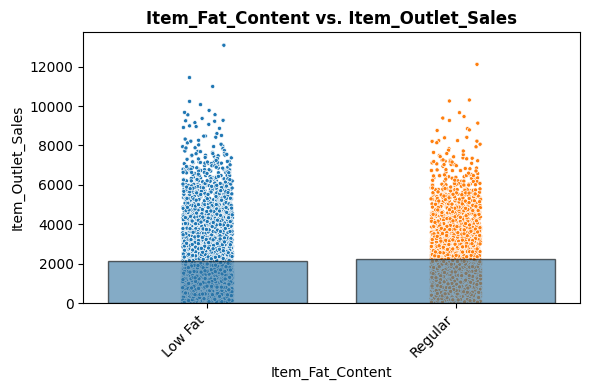

In [ ]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(new_df,feature ,'Item_Outlet_Sales' , )

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No.
  - Does this feature appear to be a predictor of the target?
    - No.

___

## Feature 4 : { Age}

-  Age

In [ ]:
# Confirming the dtype to select correct EDA function
feature=' Age'
new_df[feature].dtype

dtype('O')

/tmp/ipykernel_766/1613442045.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


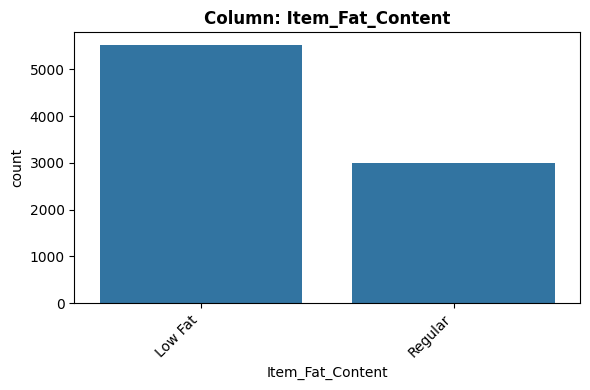

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'Low Fat' occurs 5517 times (64.73%)
- Not constant or quasi-constant.


In [ ]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(new_df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - categorical

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 2 unique values (low)

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  -No



/tmp/ipykernel_766/2400736708.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Fat_Content vs. Item_Outlet_Sales'}, xlabel='Item_Fat_Content', ylabel='Item_Outlet_Sales'>)

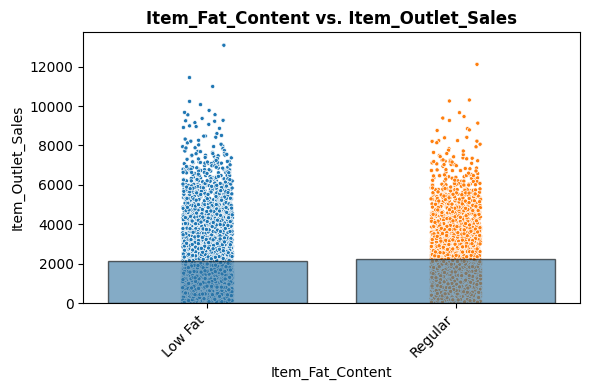

In [ ]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(new_df,feature ,'Item_Outlet_Sales' , )

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No.
  - Does this feature appear to be a predictor of the target?
    - No.

___

## Feature 5 : {Gender}

- Gender

In [ ]:
# Confirming the dtype to select correct EDA function
feature='Gender'
new_df[feature].dtype

dtype('O')

/tmp/ipykernel_766/1613442045.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


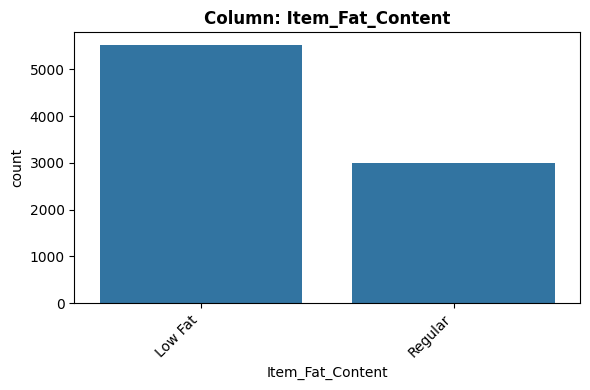

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'Low Fat' occurs 5517 times (64.73%)
- Not constant or quasi-constant.


In [ ]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(new_df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - categorical

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 2 unique values (low)

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  -No



/tmp/ipykernel_766/2400736708.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Fat_Content vs. Item_Outlet_Sales'}, xlabel='Item_Fat_Content', ylabel='Item_Outlet_Sales'>)

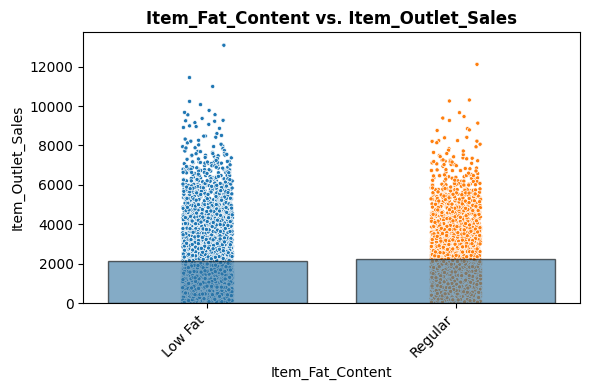

In [ ]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(new_df,feature ,'Item_Outlet_Sales' , )

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No.
  - Does this feature appear to be a predictor of the target?
    - No.

___